## Socratic Synthesizer(Deep Research & Critical Thinking)

- 이름: Socratic Synthesizer (소크라테스식 신서사이저)

- 목적: 사용자의 주장에 대해 편향되지 않은 심층 분석을 제공하고, 비판적 사고를 촉진함.

- 핵심 기능:

    - Support Node: 사용자의 가설을 뒷받침하는 데이터와 논리적 근거를 수집/생성.

    - Socrates Node (Adversarial): 생성된 근거의 허점을 찾고 반대 사례(Counter-arguments)를 제시.

    - Synthesis Node: 양측의 의견을 종합하여 최종적인 다각도 분석 보고서 작성.

- 그래프 구조:
Input -> Research_Support -> Socratic_Critic -> Final_Synthesizer -> End

In [6]:
import operator
from typing import TypedDict, List, Optional
from langgraph.graph import StateGraph, END, START
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage


In [2]:
# 1. Define the Schema (State)
# We use a custom State to keep specific parts of the reasoning process separate.
class SocraticState(TypedDict):
    user_claim: str           # The original input
    supporting_points: str    # Output from the first agent
    adversarial_critique: str # Output from the Socratic agent
    final_report: str         # The integrated output

# Initialize LLM - Using a high-reasoning model for Socratic depth
llm = ChatOpenAI(model="gpt-4o")

In [ ]:
# 2. Define the Nodes

def support_node(state: SocraticState):
    """Generates the strongest possible defense for the user's claim."""
    prompt = f"""
    Role: Senior Research Analyst.
    Task: Provide a structured, evidence-based defense for the following claim.
    Claim: {state['user_claim']}
    
    Requirements:
    - Provide 3 distinct pillars of support.
    - Use logical frameworks (e.g., economic utility, historical precedent).
    """
    response = llm.invoke(prompt)
    return {"supporting_points": response.content}


def socratic_node(state: SocraticState):
    """Acts as the Devil's Advocate to challenge the support provided."""
    prompt = f"""
    Role: Socratic Adversary / Critical Thinker.
    Task: Scrutinize the following claim and its supporting evidence.
    
    Claim: {state['user_claim']}
    Supporting Evidence: {state['supporting_points']}
    
    Requirements:
    - Identify 'blind spots' or logical fallacies in the evidence.
    - Present 2 strong counter-arguments.
    - Challenge the underlying assumptions.
    """
    response = llm.invoke(prompt)
    return {"adversarial_critique": response.content}


def synthesis_node(state: SocraticState):
    """Integrates both perspectives into a sophisticated conclusion."""
    prompt = f"""
    Role: Neutral Moderator & Synthesizer.
    Task: Create a comprehensive 'State of the Debate' report.
    
    Original Claim: {state['user_claim']}
    The Defense: {state['supporting_points']}
    The Critique: {state['adversarial_critique']}
    
    Structure:
    1. Executive Summary
    2. Strengths of the Argument
    3. Critical Vulnerabilities
    4. Synthesis: A nuanced middle-ground or advanced perspective.
    """
    response = llm.invoke(prompt)
    return {"final_report": response.content}


In [7]:

# 3. Build the Graph

workflow = StateGraph(SocraticState)

# Add Nodes
workflow.add_node("researcher", support_node)
workflow.add_node("socrates", socratic_node)
workflow.add_node("integrator", synthesis_node)

# Connect Edges (Linear Logic Flow)
workflow.add_edge(START, "researcher")
workflow.add_edge("researcher", "socrates")
workflow.add_edge("socrates", "integrator")
workflow.add_edge("integrator", END)

# Compile the Graph
app = workflow.compile()


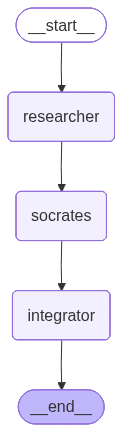

In [8]:
app